### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there â€˜right awayâ€™ or â€˜later before the coupon expiresâ€™ are labeled as â€˜Y = 1â€™ and answers â€˜no, I do not want the couponâ€™ are labeled as â€˜Y = 0â€™.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [37]:
data = pd.read_csv('data/coupons.csv')

In [38]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [39]:
print(f"Dataset shape: {data.shape}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values per column:\n{data.isnull().sum()}")
print(f"\nPercentage of missing values:\n{(data.isnull().sum() / len(data) * 100).round(2)}")
print(f"\nDuplicate rows: {data.duplicated().sum()}")
data.describe(include='all')

Dataset shape: (12684, 26)

Data types:
destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object

Missing values per column:
destination                 0
passanger                   0
weather                     0
temperature           

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684,12684,12684,12684.000000,12684,12684,12684,12684,12684,12684,...,12467,12533,12554,12495,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
unique,3,4,3,NaN,5,5,2,2,8,5,...,5,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
top,No Urgent Place,Alone,Sunny,NaN,6PM,Coffee House,1d,Female,21,Married partner,...,less1,1~3,1~3,less1,NaN,NaN,NaN,NaN,NaN,NaN
freq,6283,7305,10069,NaN,3230,3996,7091,6511,2653,5100,...,3385,4672,5376,6077,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.301798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,NaN,NaN,NaN,19.154486,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000


3. Decide what to do about your missing data -- drop, replace, other...

In [40]:
# The 'car' column has the most missing values (~99%). Dropping it since it's not useful
data['car'].unique()
data['car'].value_counts()
data = data.drop(columns=['car'])

# For the remaining categorical columns with missing values (Bar, CoffeeHouse, CarryAway,
# RestaurantLessThan20, Restaurant20To50), fill with the mode or drop rows
# Since the missing percentage is small (~1%), we can safely drop those rows
data = data.dropna()

print(f"Dataset shape after cleaning: {data.shape}")
print(f"Remaining missing values: {data.isnull().sum().sum()}")

Dataset shape after cleaning: (12079, 25)
Remaining missing values: 0


4. What proportion of the total observations chose to accept the coupon?



In [41]:
acceptance_rate = data['Y'].mean()
print(f"Proportion of drivers who accepted the coupon: {acceptance_rate:.4f} ({acceptance_rate*100:.2f}%)")
print(f"Accepted: {data['Y'].sum()} out of {len(data)} total rows")

Proportion of drivers who accepted the coupon: 0.5693 (56.93%)
Accepted: 6877 out of 12079 total rows


5. Use a bar plot to visualize the `coupon` column.

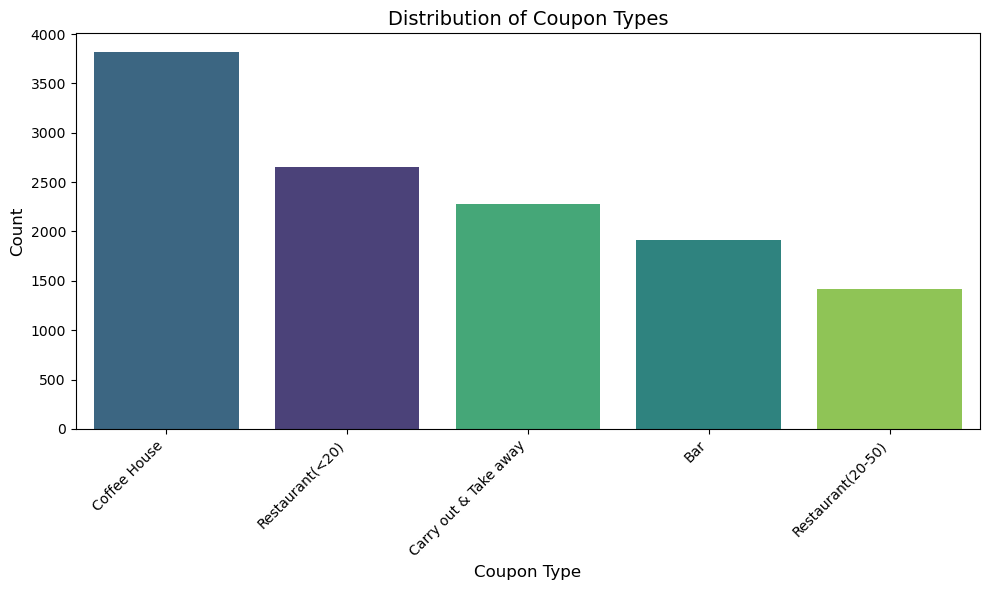

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(x='coupon', hue='coupon', data=data, order=data['coupon'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribution of Coupon Types', fontsize=14)
plt.xlabel('Coupon Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

In [43]:
data['temperature'].unique()
data['temperature'].value_counts()

temperature
80    6222
55    3662
30    2195
Name: count, dtype: int64

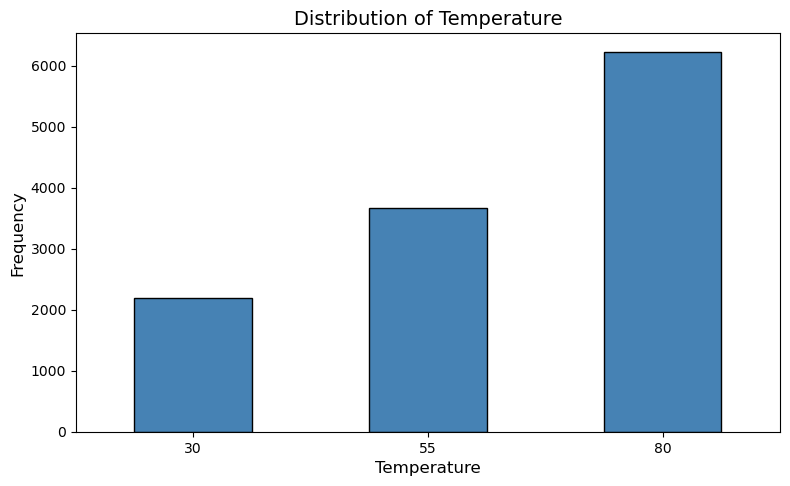

In [44]:
plt.figure(figsize=(8, 5))
data['temperature'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Temperature', fontsize=14)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

#### Acceptance Rate by Coupon Type

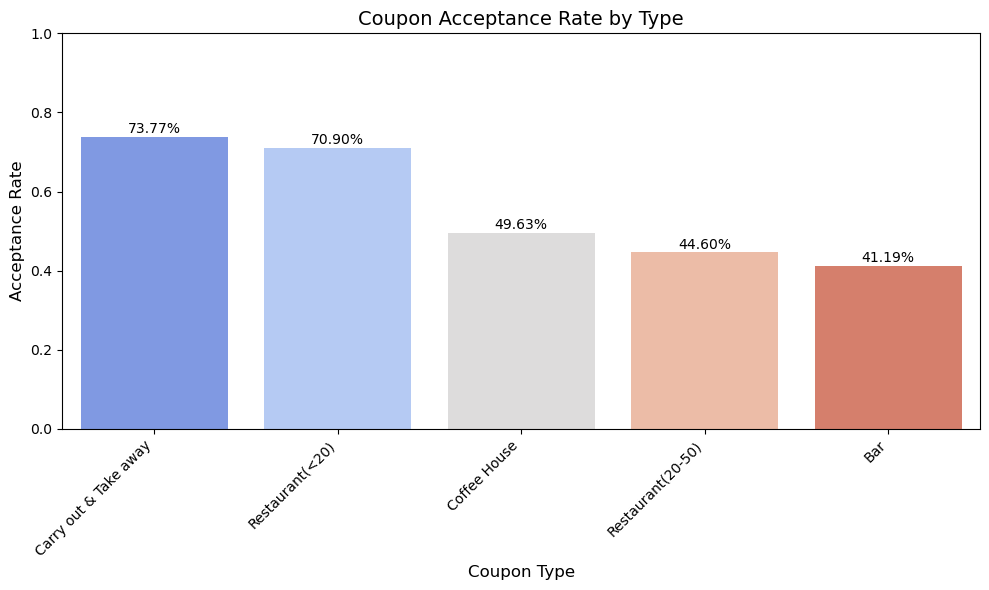

In [45]:
coupon_acceptance = data.groupby('coupon')['Y'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=coupon_acceptance.index, y=coupon_acceptance.values, hue=coupon_acceptance.index, palette='coolwarm', legend=False)
plt.title('Coupon Acceptance Rate by Type', fontsize=14)
plt.xlabel('Coupon Type', fontsize=12)
plt.ylabel('Acceptance Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(coupon_acceptance.values):
    ax.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### Acceptance Rate by Passenger Type and Weather

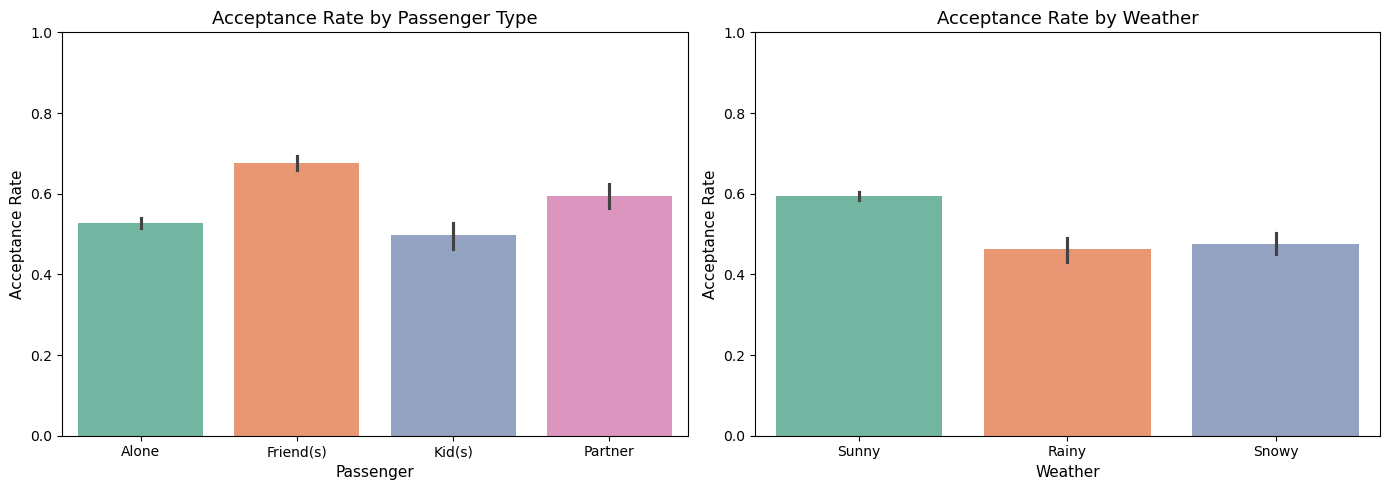

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='passanger', y='Y', hue='passanger', data=data, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Acceptance Rate by Passenger Type', fontsize=13)
axes[0].set_xlabel('Passenger', fontsize=11)
axes[0].set_ylabel('Acceptance Rate', fontsize=11)
axes[0].set_ylim(0, 1)

sns.barplot(x='weather', y='Y', hue='weather', data=data, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Acceptance Rate by Weather', fontsize=13)
axes[1].set_xlabel('Weather', fontsize=11)
axes[1].set_ylabel('Acceptance Rate', fontsize=11)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [47]:
bar_coupons = data[data['coupon'] == 'Bar']
print(f"Number of bar coupon observations: {len(bar_coupons)}")
bar_coupons.head()

Number of bar coupon observations: 1913


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [48]:
bar_acceptance_rate = bar_coupons['Y'].mean()
print(f"Proportion of bar coupons accepted: {bar_acceptance_rate:.4f} ({bar_acceptance_rate*100:.2f}%)")

Proportion of bar coupons accepted: 0.4119 (41.19%)


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [52]:
bar_coupons['Bar'].unique()
bar_coupons['Bar'].value_counts()

Bar
never    788
less1    553
1~3      379
4~8      147
gt8       46
Name: count, dtype: int64

Acceptance rate: went to bar 3 or fewer times/month: 0.3727 (37.27%)
Acceptance rate: went to bar more than 3 times/month: 0.7617 (76.17%)


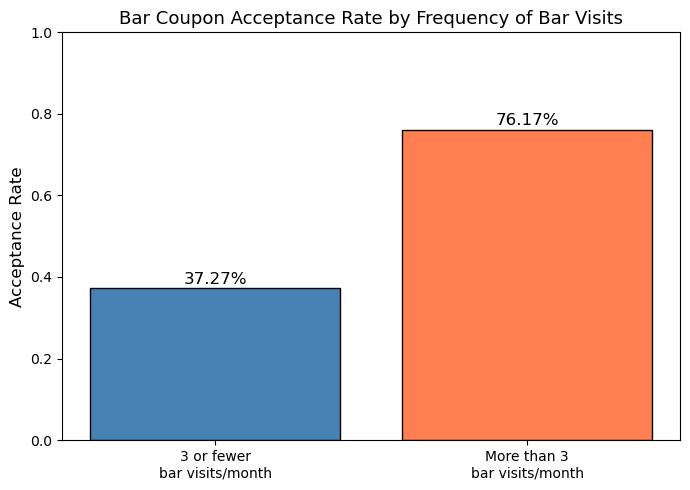

In [55]:
# Those who went to a bar 3 or fewer times: 'never', 'less1', '1~3'
# Those who went more than 3 times: '4~8', 'gt8'
bar_3_or_fewer = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]
bar_more_than_3 = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]

rate_3_or_fewer = bar_3_or_fewer['Y'].mean()
rate_more_than_3 = bar_more_than_3['Y'].mean()

print(f"Acceptance rate: went to bar 3 or fewer times/month: {rate_3_or_fewer:.4f} ({rate_3_or_fewer*100:.2f}%)")
print(f"Acceptance rate: went to bar more than 3 times/month: {rate_more_than_3:.4f} ({rate_more_than_3*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
categories = ['3 or fewer\nbar visits/month', 'More than 3\nbar visits/month']
rates = [rate_3_or_fewer, rate_more_than_3]
bars = ax.bar(categories, rates, color=['steelblue', 'coral'], edgecolor='black')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{rate:.2%}', ha='center', fontsize=12)
ax.set_title('Bar Coupon Acceptance Rate by Frequency of Bar Visits', fontsize=13)
ax.set_ylabel('Acceptance Rate', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [54]:
bar_coupons['age'].unique()
bar_coupons['age'].value_counts()

age
21         397
26         368
31         324
50plus     273
36         196
41         171
46         103
below21     81
Name: count, dtype: int64

Acceptance rate:  bar >1/month AND age >25: 0.6898 (68.98%)
Acceptance rate:  all others:                0.3377 (33.77%)

Difference: 35.21 percentage points


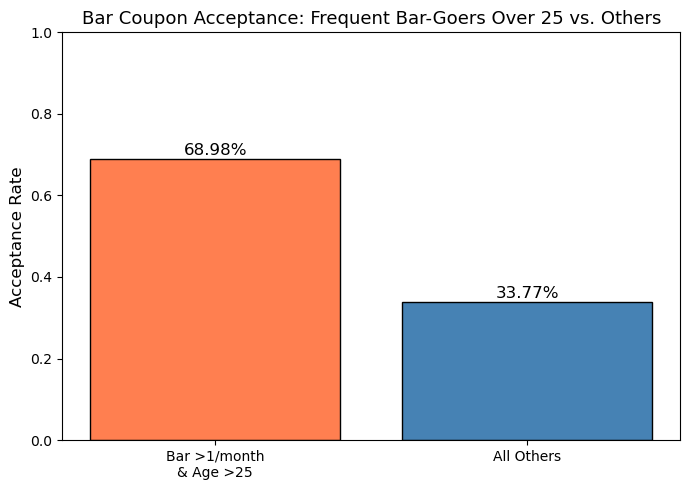

In [56]:
# Drivers who go to a bar more than once a month: '1~3', '4~8', 'gt8'
# and are over 25
bar_more_than_once = bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])
over_25 = ~bar_coupons['age'].isin(['21', 'below21'])

group1 = bar_coupons[bar_more_than_once & over_25]
group2 = bar_coupons[~(bar_more_than_once & over_25)]

rate_group1 = group1['Y'].mean()
rate_group2 = group2['Y'].mean()

print(f"Acceptance rate:  bar >1/month AND age >25: {rate_group1:.4f} ({rate_group1*100:.2f}%)")
print(f"Acceptance rate:  all others:                {rate_group2:.4f} ({rate_group2*100:.2f}%)")
print(f"\nDifference: {(rate_group1 - rate_group2)*100:.2f} percentage points")

fig, ax = plt.subplots(figsize=(7, 5))
categories = ['Bar >1/month\n& Age >25', 'All Others']
rates = [rate_group1, rate_group2]
bars = ax.bar(categories, rates, color=['coral', 'steelblue'], edgecolor='black')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{rate:.2%}', ha='center', fontsize=12)
ax.set_title('Bar Coupon Acceptance: Frequent Bar-Goers Over 25 vs. Others', fontsize=13)
ax.set_ylabel('Acceptance Rate', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate:  bar >1/month, no kids, not farming/fishing/forestry: 0.7094 (70.94%)
Acceptance rate:  all others: 0.2979 (29.79%)

Difference: 41.15 percentage points


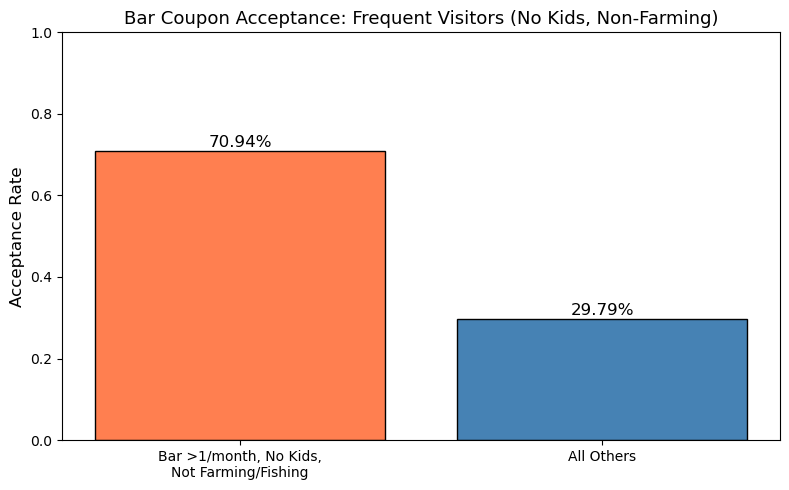

In [57]:
bar_more_than_once = bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])
not_kid_passenger = bar_coupons['passanger'] != 'Kid(s)'
not_farming = bar_coupons['occupation'] != 'Farming Fishing & Forestry'

group_target = bar_coupons[bar_more_than_once & not_kid_passenger & not_farming]
group_other = bar_coupons[~(bar_more_than_once & not_kid_passenger & not_farming)]

rate_target = group_target['Y'].mean()
rate_other = group_other['Y'].mean()

print(f"Acceptance rate:  bar >1/month, no kids, not farming/fishing/forestry: {rate_target:.4f} ({rate_target*100:.2f}%)")
print(f"Acceptance rate:  all others: {rate_other:.4f} ({rate_other*100:.2f}%)")
print(f"\nDifference: {(rate_target - rate_other)*100:.2f} percentage points")

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Bar >1/month, No Kids,\nNot Farming/Fishing', 'All Others']
rates = [rate_target, rate_other]
bars = ax.bar(categories, rates, color=['coral', 'steelblue'], edgecolor='black')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{rate:.2%}', ha='center', fontsize=12)
ax.set_title('Bar Coupon Acceptance: Frequent Visitors (No Kids, Non-Farming)', fontsize=13)
ax.set_ylabel('Acceptance Rate', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Acceptance rate:  combined group (A or B or C): 0.6067 (60.67%)
Acceptance rate:  all others:                   0.5432 (54.32%)

Difference: 6.35 percentage points


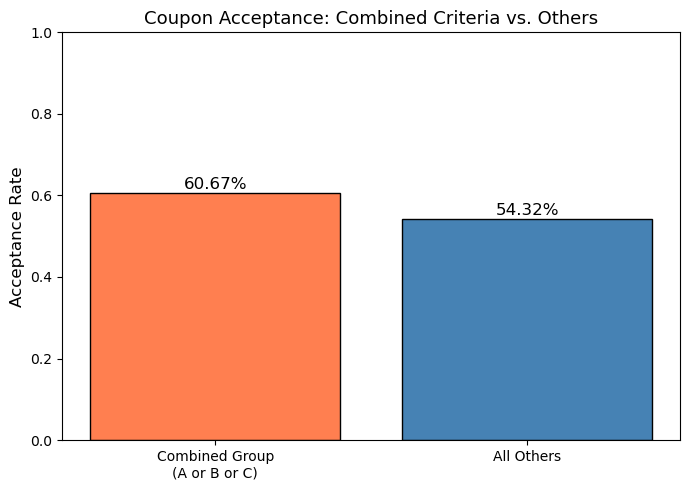

In [58]:
# Group A: go to bars >1/month, no kid passengers, not widowed
bar_gt1 = data['Bar'].isin(['1~3', '4~8', 'gt8'])
not_kid = data['passanger'] != 'Kid(s)'
not_widowed = data['maritalStatus'] != 'Widowed'
group_a = bar_gt1 & not_kid & not_widowed

# Group B: go to bars >1/month and under age 30
under_30 = data['age'].isin(['below21', '21', '26'])
group_b = bar_gt1 & under_30

# Group C: go to cheap restaurants >4 times/month and income < 50K
cheap_rest_gt4 = data['RestaurantLessThan20'].isin(['4~8', 'gt8'])
income_lt_50k = data['income'].isin([
    'Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'
])
group_c = cheap_rest_gt4 & income_lt_50k

combined_group = data[group_a | group_b | group_c]
others = data[~(group_a | group_b | group_c)]

rate_combined = combined_group['Y'].mean()
rate_others = others['Y'].mean()

print(f"Acceptance rate:  combined group (A or B or C): {rate_combined:.4f} ({rate_combined*100:.2f}%)")
print(f"Acceptance rate:  all others:                   {rate_others:.4f} ({rate_others*100:.2f}%)")
print(f"\nDifference: {(rate_combined - rate_others)*100:.2f} percentage points")

fig, ax = plt.subplots(figsize=(7, 5))
categories = ['Combined Group\n(A or B or C)', 'All Others']
rates = [rate_combined, rate_others]
bars = ax.bar(categories, rates, color=['coral', 'steelblue'], edgecolor='black')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{rate:.2%}', ha='center', fontsize=12)
ax.set_title('Coupon Acceptance: Combined Criteria vs. Others', fontsize=13)
ax.set_ylabel('Acceptance Rate', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**Hypothesis about drivers who accepted bar coupons:**

1. **Frequency of bar visits matters most**: Drivers who already visit bars more than 3 times a month are significantly more likely to accept bar coupons. This is the strongest indicator. Habitual bar-goers are naturally more receptive of the coupons.

2. **Age plays a role**: Younger drivers (under 30) and those over 25 who are frequent bar visitors both show higher acceptance rates. The combination of youth and existing bar-going behavior is a strong indicator.

3. **Passenger context matters**: Drivers without children as passengers are more likely to accept bar coupons, which makes sense taking kids to a bar is less practical.

4. **economic factors**: Drivers who eat at cheap restaurants frequently and have lower incomes also show higher acceptance, suggesting price-conscious consumers who dine out often are open to bar coupon deals.

Overall, the data suggests that bar coupons are most effective for younger, socially active individuals who already frequents bars, typically without children in the car, and across various occupations (except farming/fishing/forestry).

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Independent Investigation: Coffee House Coupons

Coffee House coupons are the most common coupon type in the dataset.

In [59]:
coffee = data[data['coupon'] == 'Coffee House']
coffee_rate = coffee['Y'].mean()
print(f"Total Coffee House coupon observations: {len(coffee)}")
print(f"Overall Coffee House acceptance rate: {coffee_rate:.4f} ({coffee_rate*100:.2f}%)")

Total Coffee House coupon observations: 3816
Overall Coffee House acceptance rate: 0.4963 (49.63%)



Acceptance rate by coffee house visit frequency:
             Acceptance Rate  Count
CoffeeHouse                        
4~8                 0.682446    507
gt8                 0.657895    342
1~3                 0.647694   1019
less1               0.480989   1052
never               0.175223    896


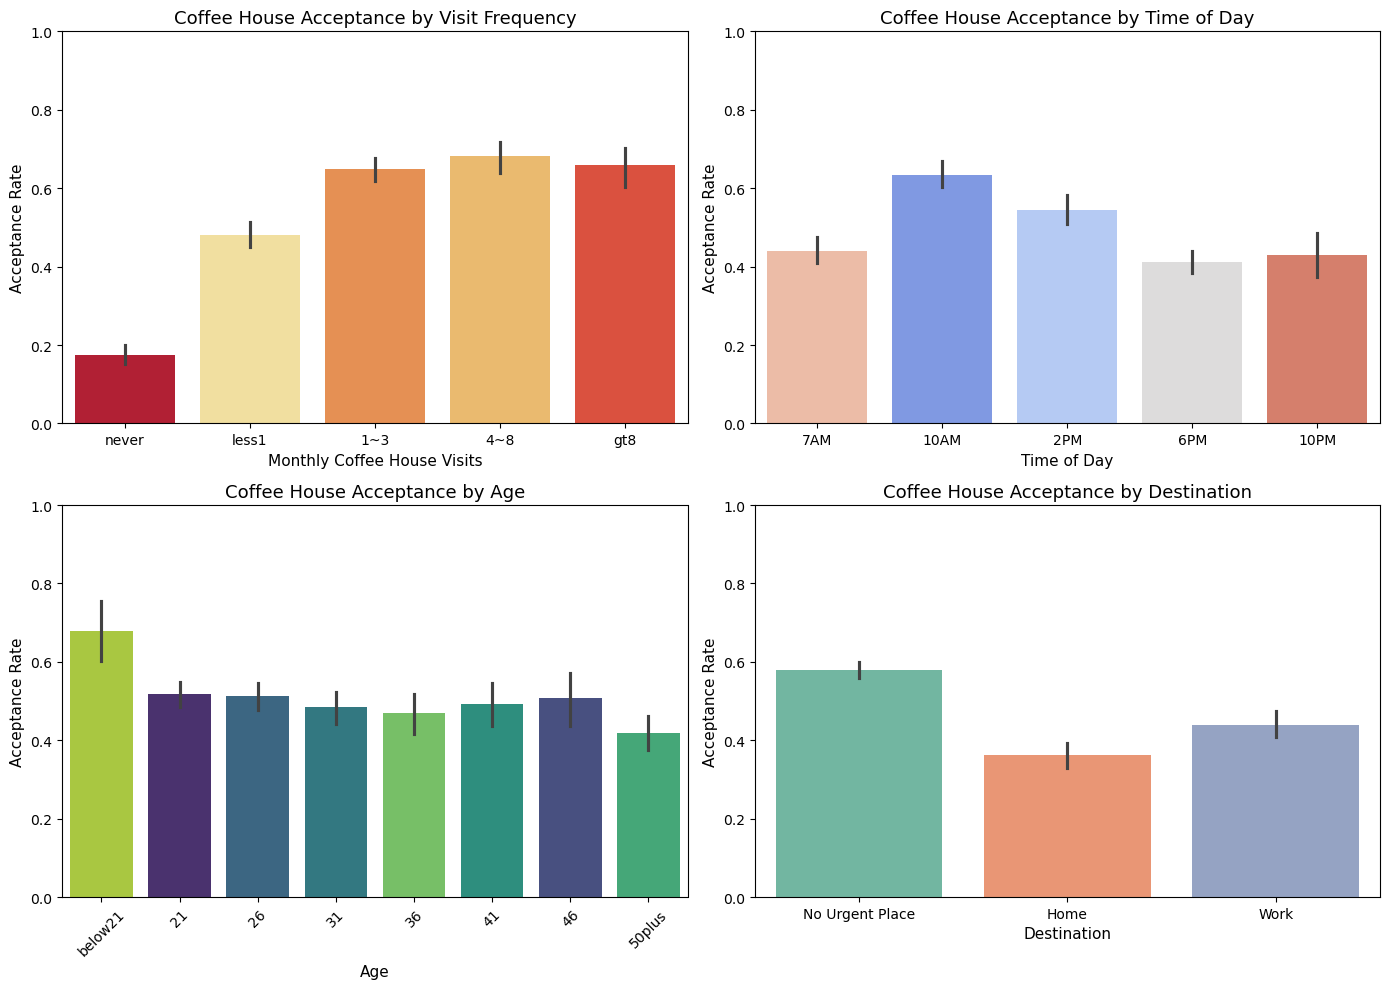

In [60]:
# Acceptance rate by coffee house visit frequency
coffee_by_freq = coffee.groupby('CoffeeHouse')['Y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
coffee_by_freq.columns = ['Acceptance Rate', 'Count']
print(f"\nAcceptance rate by coffee house visit frequency:\n{coffee_by_freq}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Acceptance by Coffee House visit frequency
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
sns.barplot(x='CoffeeHouse', y='Y', hue='CoffeeHouse', data=coffee, order=freq_order, palette='YlOrRd', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Coffee House Acceptance by Visit Frequency', fontsize=13)
axes[0, 0].set_xlabel('Monthly Coffee House Visits', fontsize=11)
axes[0, 0].set_ylabel('Acceptance Rate', fontsize=11)
axes[0, 0].set_ylim(0, 1)

# 2. Acceptance by time of day
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
sns.barplot(x='time', y='Y', hue='time', data=coffee, order=time_order, palette='coolwarm', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Coffee House Acceptance by Time of Day', fontsize=13)
axes[0, 1].set_xlabel('Time of Day', fontsize=11)
axes[0, 1].set_ylabel('Acceptance Rate', fontsize=11)
axes[0, 1].set_ylim(0, 1)

# 3. Acceptance by age
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
sns.barplot(x='age', y='Y', hue='age', data=coffee, order=age_order, palette='viridis', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Coffee House Acceptance by Age', fontsize=13)
axes[1, 0].set_xlabel('Age', fontsize=11)
axes[1, 0].set_ylabel('Acceptance Rate', fontsize=11)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Acceptance by destination
sns.barplot(x='destination', y='Y', hue='destination', data=coffee, palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Coffee House Acceptance by Destination', fontsize=13)
axes[1, 1].set_xlabel('Destination', fontsize=11)
axes[1, 1].set_ylabel('Acceptance Rate', fontsize=11)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [61]:
# Deeper comparisons for Coffee House coupons

# Frequent coffee drinkers (>1/month) vs infrequent
frequent_coffee = coffee[coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]
infrequent_coffee = coffee[coffee['CoffeeHouse'].isin(['never', 'less1'])]
print(f"Frequent coffee-goers (>1/month) acceptance rate: {frequent_coffee['Y'].mean():.2%}")
print(f"Infrequent coffee-goers acceptance rate: {infrequent_coffee['Y'].mean():.2%}")

# Morning (7AM, 10AM) vs afternoon/evening
morning = coffee[coffee['time'].isin(['7AM', '10AM'])]
afternoon_evening = coffee[coffee['time'].isin(['2PM', '6PM', '10PM'])]
print(f"\nMorning coupon acceptance rate: {morning['Y'].mean():.2%}")
print(f"Afternoon/Evening coupon acceptance rate: {afternoon_evening['Y'].mean():.2%}")

# Alone vs with friends
alone = coffee[coffee['passanger'] == 'Alone']
with_friends = coffee[coffee['passanger'] == 'Friend(s)']
print(f"\nDriving alone acceptance rate: {alone['Y'].mean():.2%}")
print(f"With friends acceptance rate: {with_friends['Y'].mean():.2%}")

# Expiration time comparison
exp_2h = coffee[coffee['expiration'] == '2h']
exp_1d = coffee[coffee['expiration'] == '1d']
print(f"\n2-hour expiration acceptance rate: {exp_2h['Y'].mean():.2%}")
print(f"1-day expiration acceptance rate: {exp_1d['Y'].mean():.2%}")

# Gender comparison
male = coffee[coffee['gender'] == 'Male']
female = coffee[coffee['gender'] == 'Female']
print(f"\nMale acceptance rate: {male['Y'].mean():.2%}")
print(f"Female acceptance rate: {female['Y'].mean():.2%}")

Frequent coffee-goers (>1/month) acceptance rate: 65.90%
Infrequent coffee-goers acceptance rate: 34.03%

Morning coupon acceptance rate: 53.64%
Afternoon/Evening coupon acceptance rate: 46.31%

Driving alone acceptance rate: 43.39%
With friends acceptance rate: 59.74%

2-hour expiration acceptance rate: 42.91%
1-day expiration acceptance rate: 58.06%

Male acceptance rate: 50.19%
Female acceptance rate: 49.11%


#### Coffee House Coupon Findings

**Key observations:**

1. Frequent coffee house visitors (1-3+ times/month) accept coupons at a much higher rate
   than infrequent visitors, mirroring the pattern seen with bar coupons.

2. Morning (10AM) and afternoon (2PM) are peak acceptance times — coffee is a morning/afternoon habit, so coupons delivered at those times align with natural behavior.

3. Younger drivers (under 30) tend to have higher acceptance rates for coffee house coupons.

4. Drivers with "No Urgent Place" as their destination are much more likely to accept coffee house coupons compared to those heading to work or home. The lack of time pressure makes detours more appealing.

5. Coupons with a 1-day expiration window are accepted at higher rates than 2-hour coupons, giving drivers flexibility to use them later.

6. Drivers with friends as passengers show slightly higher acceptance rates than those driving alone, suggesting a social component to coffee house visits.
